# Analyse Exploratoire des Données (EDA)
## Projet : Système Intelligent de Maintenance Prédictive Industrielle

**EFREI – M2 Data Engineering & AI | 2025**  
**Auteurs :**  William BLENON & Véronèse Nikina ZINSOU

**Encadrante :** Sarah Malaeb
 
**Dataset :** `industrial_machine_maintenance.csv` – 24 042 enregistrements · 15 variables  
**Tâche choisie :** Classification binaire – `failure_within_24h`

---

## Objectifs de l'EDA

1. **Comprendre la structure des données** : types, dimensions, valeurs manquantes, doublons.
2. **Analyser les distributions** : identifier les outliers, asymétries, valeurs aberrantes.
3. **Étudier le déséquilibre des classes** : évaluer l'impact sur la modélisation.
4. **Identifier les corrélations** : repérer les features discriminantes et les redondances.

> **Note méthodologique :** Ces visualisations appuient la démarche scientifique et le rapport technique.
> Elles ne sont **pas** intégrées dans le dashboard décisionnel, qui est orienté utilisateur métier.

---
## Cellule 1 - Imports, configuration et chargement des données

> **Exécuter cette cellule EN PREMIER.** Elle initialise toutes les variables (`df`, `loader`, `plt`, etc.)
> utilisées par les cellules suivantes.

In [12]:
# ══════════════════════════════════════════════════════════════
# CELLULE 1 — À exécuter en premier (initialisation complète)
# ══════════════════════════════════════════════════════════════

# ── Bibliothèques standard ────────────────────────────────────
import warnings
import sys
import os
warnings.filterwarnings('ignore')

# ── Manipulation de données ───────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats

# ── Visualisation (matplotlib + seaborn uniquement pour l'EDA) -
# Plotly est réservé au dashboard Streamlit (interactif)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Configuration visuelle ────────────────────────────────────
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_palette('husl')
COLOR_OK    = '#2ecc71'   # vert  = pas de panne
COLOR_FAIL  = '#e74c3c'   # rouge = panne imminente
COLORS      = [COLOR_OK, COLOR_FAIL]

# ── Ajout du répertoire racine du projet au path ──────────────
# Nécessaire pour importer les modules src/ depuis notebooks/
ROOT_DIR = os.path.abspath('..')
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

# ── Chargement via DataLoader ─────────────────────────────────
from src.data.data_loader import DataLoader

DATA_PATH = os.path.join(ROOT_DIR, 'data', 'industrial_machine_maintenance.csv')

loader = DataLoader(DATA_PATH)
df = loader.load()

# ── Colonnes numériques utilisées dans toutes les cellules ────
# Colonnes numeriques reelles du dataset (validees apres inspection)
NUMERIC_COLS = ['vibration_rms', 'temperature_motor', 'current_phase_avg',
               'pressure_level', 'rpm', 'hours_since_maintenance',
               'ambient_temp', 'rul_hours']
NUMERIC_COLS = [c for c in NUMERIC_COLS if c in df.columns]
TARGET       = 'failure_within_24h'

print('Imports et chargement OK.')
print(f'Python {sys.version.split()[0]} | pandas {pd.__version__} | numpy {np.__version__}')
print(f'Dataset : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')
print(f'Colonnes numériques : {NUMERIC_COLS}')
print(f'Colonnes numériques : {NUMERIC_COLS_VALID}')

[DataLoader] Dataset chargé avec succès.
  → 24042 enregistrements | 15 variables
Imports et chargement OK.
Python 3.9.6 | pandas 2.3.3 | numpy 1.23.5
Dataset : 24,042 lignes x 15 colonnes
Colonnes numériques : ['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'rul_hours']


NameError: name 'NUMERIC_COLS_VALID' is not defined

---
## Cellule 2 — Inspection initiale du dataset

In [ ]:
# ── Inspection via DataLoader ─────────────────────────────────
info = loader.get_info()

print('=' * 58)
print(f'  Dimensions    : {info["shape"][0]:,} lignes x {info["shape"][1]} colonnes')
print(f'  Mémoire       : {info["memory_usage_mb"]} Mo')
print(f'  Doublons      : {info["duplicates"]}')
print('=' * 58)
print(f'\n{"Colonne":<30} {"Type":<12} {"Manquants":>10} {"Pct":>8}')
print('-' * 64)
for col, dtype in info['dtypes'].items():
    missing = info['missing_values'][col]
    pct     = info['missing_percent'][col]
    flag    = '  !' if missing > 0 else ''
    print(f'  {col:<28} {dtype:<12} {missing:>10} {pct:>7.2f}%{flag}')

  Dimensions    : 24,042 lignes x 15 colonnes
  Mémoire       : 8.07 Mo
  Doublons      : 0

Colonne                        Type          Manquants      Pct
----------------------------------------------------------------
  timestamp                    object                0    0.00%
  machine_id                   int64                 0    0.00%
  machine_type                 object                0    0.00%
  vibration_rms                float64            1000    4.16%  !
  temperature_motor            float64             834    3.47%  !
  current_phase_avg            float64             731    3.04%  !
  pressure_level               float64             924    3.84%  !
  rpm                          float64             533    2.22%  !
  operating_mode               object                0    0.00%
  hours_since_maintenance      float64               0    0.00%
  ambient_temp                 float64               0    0.00%
  rul_hours                    float64               0    0

In [ ]:
# ── Aperçu des premières lignes ───────────────────────────────
df.head(10)

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0
5,2024-01-01 01:23:00,1,CNC,0.94,42.00,4.77,23.6,853.2,idle,275.18,16.1,59.62,0,none,0
6,2024-01-01 01:47:00,1,CNC,0.88,41.71,4.10,25.7,917.6,idle,275.58,10.8,59.22,0,none,0
7,2024-01-01 01:55:00,1,CNC,2.93,54.57,10.13,78.0,2932.1,normal,275.72,11.4,59.08,0,none,0
8,2024-01-01 01:59:00,1,CNC,0.74,44.95,4.05,25.5,868.1,idle,275.78,11.6,59.02,0,none,0
9,2024-01-01 02:12:00,1,CNC,0.90,43.12,4.78,23.3,862.9,idle,276.00,16.1,58.80,0,none,0


In [ ]:
# ── Statistiques descriptives ─────────────────────────────────
df.describe(include='all').round(2)

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
count,24042,24042.00,24042,23042.00,23208.00,23311.00,23118.00,23509.00,24042,24042.00,24042.00,24042.00,24042.00,24042,24042.00
unique,21176,NaN,4,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,5,NaN
top,2024-01-01 00:00:00,NaN,Pump,NaN,NaN,NaN,NaN,NaN,normal,NaN,NaN,NaN,NaN,none,NaN
freq,20,NaN,6114,NaN,NaN,NaN,NaN,NaN,11632,NaN,NaN,NaN,NaN,20482,NaN
mean,NaN,10.51,NaN,1.62,51.40,8.82,59.01,1144.85,NaN,172.63,13.00,27.81,0.15,NaN,608.87
std,NaN,5.75,NaN,1.08,12.52,5.37,38.72,912.67,NaN,150.72,2.88,26.39,0.36,NaN,1566.79
min,NaN,1.00,NaN,0.35,28.00,2.20,10.10,124.10,NaN,0.00,8.00,0.50,0.00,NaN,0.00
25%,NaN,6.00,NaN,0.82,42.61,4.63,22.70,489.40,NaN,42.87,10.50,0.50,0.00,NaN,0.00
50%,NaN,10.00,NaN,1.27,50.06,6.43,46.30,856.00,NaN,121.61,13.00,22.57,0.00,NaN,0.00
75%,NaN,15.00,NaN,2.27,59.96,13.12,94.70,1676.00,NaN,295.58,15.50,46.41,0.00,NaN,0.00


---
## Cellule 3 — Analyse de la variable cible : déséquilibre des classes

Dans un contexte industriel, les pannes sont des événements rares. Un fort déséquilibre
peut conduire un modèle naïf à prédire systématiquement la classe majoritaire (pas de panne)
tout en affichant une accuracy élevée — sans aucune utilité pratique.

[DataLoader] ⚠️  Déséquilibre détecté sur 'failure_within_24h' : classe minoritaire = 14.81%.
  → Pensez à utiliser : stratified split, class_weight='balanced', ajustement du seuil de décision.


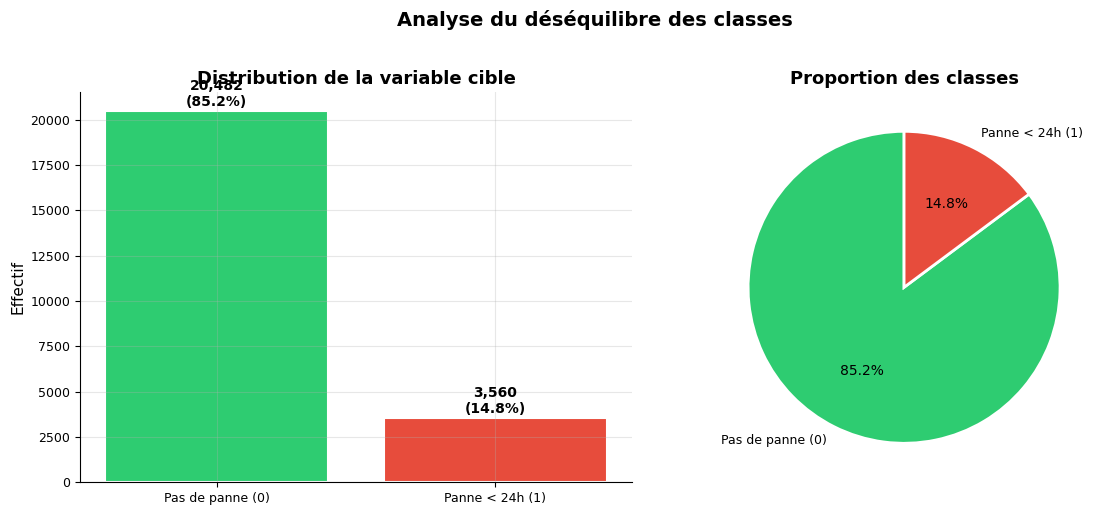

Ratio déséquilibre  : 5.8:1
Classe minoritaire  : 14.8%
Déséquilibre détecté: True

Impact sur la modélisation :
  → Utiliser stratified split pour conserver la proportion en train/test
  → Privilégier Recall et F1-Score plutôt que l'Accuracy
  → Activer class_weight="balanced" sur les modèles sklearn
  → Ajuster le seuil de décision (< 0.5 pour augmenter le Recall)


In [ ]:
dist   = loader.get_target_distribution(TARGET)
labels = ['Pas de panne (0)', 'Panne < 24h (1)']
counts = [dist['counts'].get(0, 0), dist['counts'].get(1, 0)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
bars = axes[0].bar(labels, counts, color=COLORS, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution de la variable cible', fontweight='bold')
axes[0].set_ylabel('Effectif')
for bar, count in zip(bars, counts):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{count:,}\n({count / sum(counts) * 100:.1f}%)',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

# Pie chart
axes[1].pie(
    counts, labels=labels, colors=COLORS, autopct='%1.1f%%',
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proportion des classes', fontweight='bold')

plt.suptitle('Analyse du déséquilibre des classes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Ratio déséquilibre  : {max(counts) / min(counts):.1f}:1')
print(f'Classe minoritaire  : {min(dist["percentages"].values()):.1f}%')
print(f'Déséquilibre détecté: {dist["is_imbalanced"]}')
print('\nImpact sur la modélisation :')
print('  → Utiliser stratified split pour conserver la proportion en train/test')
print('  → Privilégier Recall et F1-Score plutôt que l\'Accuracy')
print('  → Activer class_weight="balanced" sur les modèles sklearn')
print('  → Ajuster le seuil de décision (< 0.5 pour augmenter le Recall)')

---
## Cellule 4 — Distribution des variables capteurs

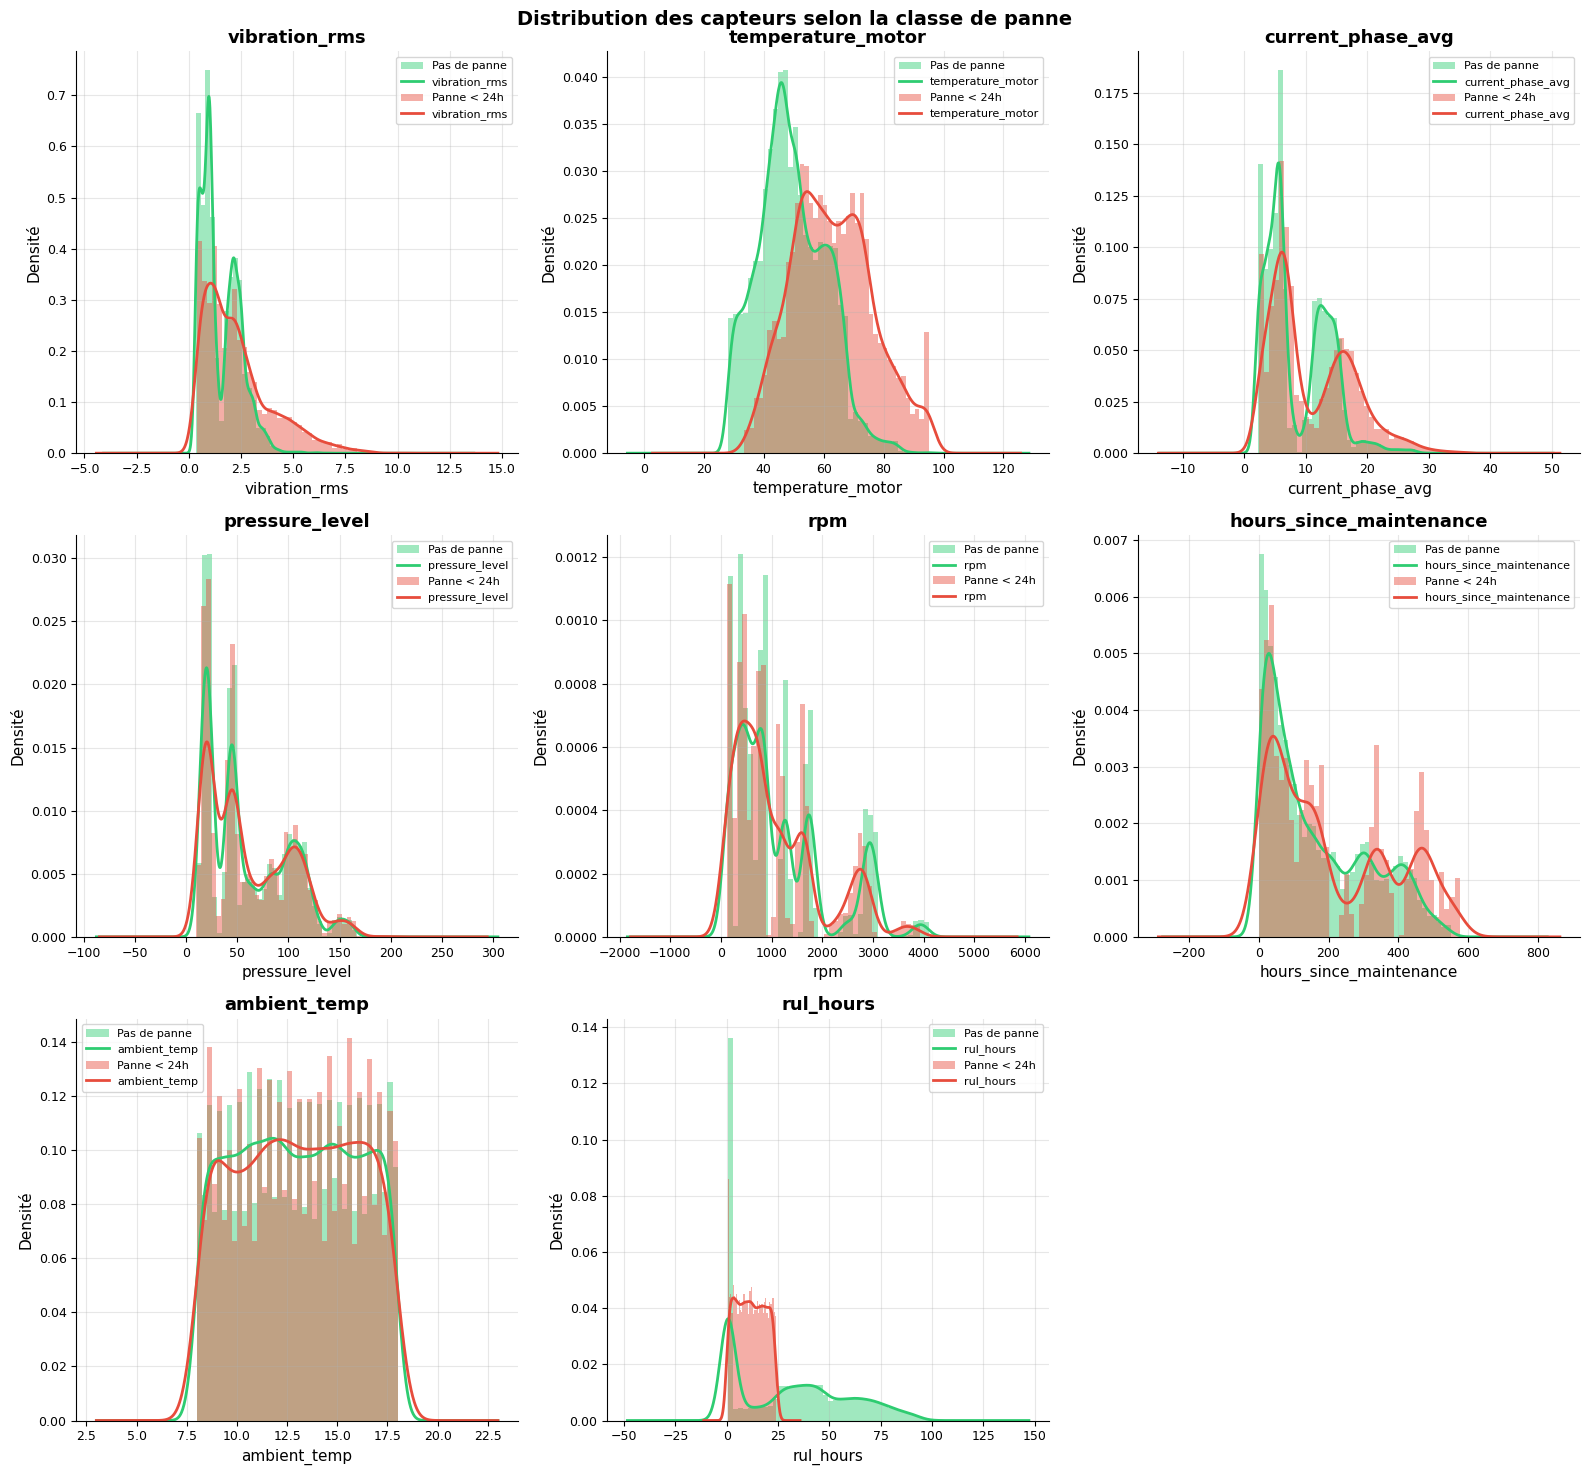

In [ ]:
# ── Histogrammes + KDE par feature ───────────────────────────
n_cols  = 3
n_rows  = (len(NUMERIC_COLS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(NUMERIC_COLS):
    ax = axes[idx]
    for label, color, name in [(0, COLOR_OK, 'Pas de panne'), (1, COLOR_FAIL, 'Panne < 24h')]:
        subset = df[df[TARGET] == label][col].dropna()
        ax.hist(subset, bins=40, alpha=0.45, color=color, label=name, density=True)
        subset.plot.kde(ax=ax, color=color, linewidth=2)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Densité')
    ax.legend(fontsize=8)

for i in range(len(NUMERIC_COLS), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Distribution des capteurs selon la classe de panne', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

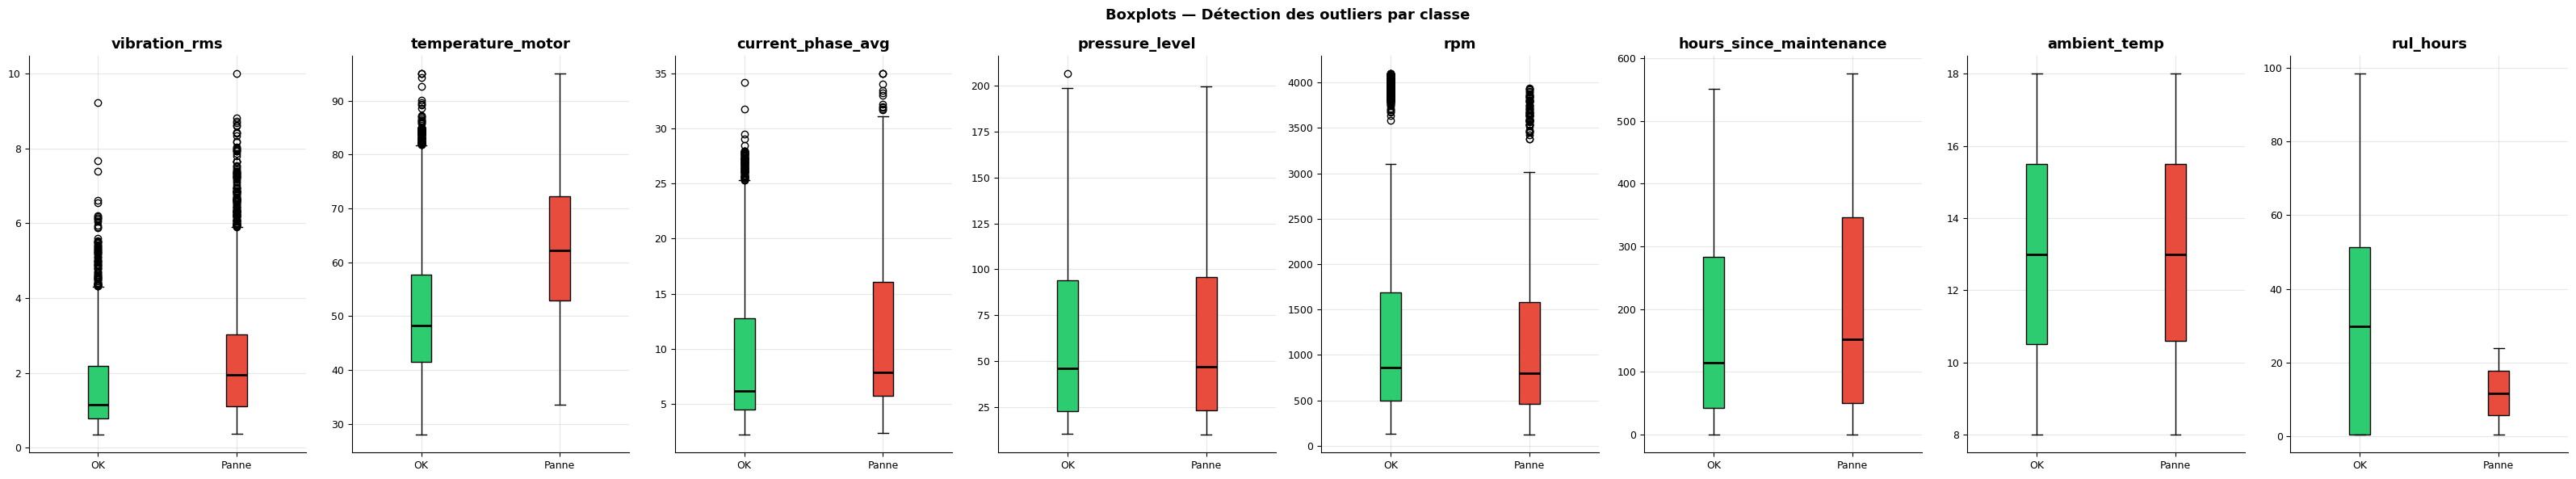


Feature                     Skewness   Interprétation
-----------------------------------------------------------------
  vibration_rms               +1.483   Fortement asymétrique -> log transform ?
  temperature_motor           +0.504   Légèrement asymétrique
  current_phase_avg           +0.841   Légèrement asymétrique
  pressure_level              +0.672   Légèrement asymétrique
  rpm                         +1.113   Fortement asymétrique -> log transform ?
  hours_since_maintenance     +0.734   Légèrement asymétrique
  ambient_temp                +0.000   Symétrique
  rul_hours                   +0.623   Légèrement asymétrique


In [ ]:
# ── Boxplots pour détecter les outliers ──────────────────────
fig, axes = plt.subplots(1, len(NUMERIC_COLS), figsize=(4 * len(NUMERIC_COLS), 6))

for idx, col in enumerate(NUMERIC_COLS):
    data_plot = [
        df[df[TARGET] == 0][col].dropna(),
        df[df[TARGET] == 1][col].dropna()
    ]
    bp = axes[idx].boxplot(
        data_plot, patch_artist=True,
        medianprops={'color': 'black', 'linewidth': 2}
    )
    bp['boxes'][0].set_facecolor(COLOR_OK)
    bp['boxes'][1].set_facecolor(COLOR_FAIL)
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].set_xticklabels(['OK', 'Panne'])

plt.suptitle('Boxplots — Détection des outliers par classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Skewness
print(f'\n{"Feature":<25} {"Skewness":>10}   Interprétation')
print('-' * 65)
for col in NUMERIC_COLS:
    sk = df[col].skew()
    if abs(sk) < 0.5:
        interp = 'Symétrique'
    elif abs(sk) < 1.0:
        interp = 'Légèrement asymétrique'
    else:
        interp = 'Fortement asymétrique -> log transform ?'
    print(f'  {col:<23} {sk:>+10.3f}   {interp}')

---
## Cellule 5 — Variables catégorielles

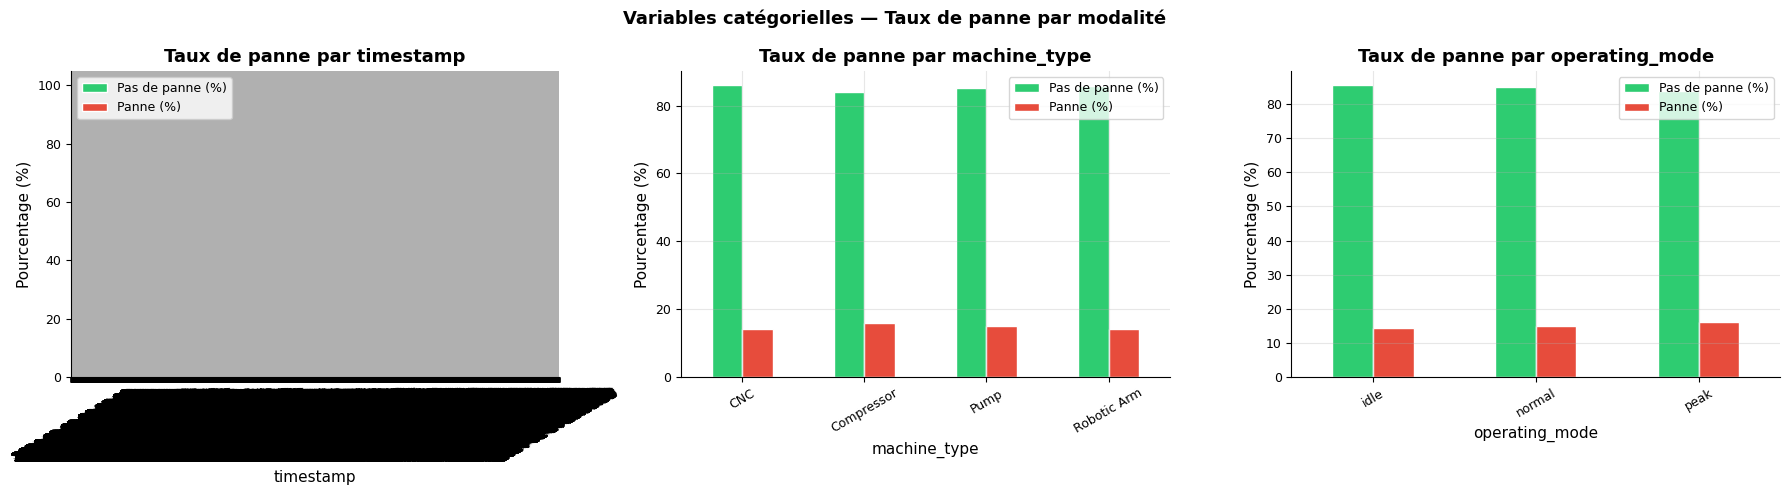

In [ ]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['failure_type']]

if cat_cols:
    n = len(cat_cols)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    for idx, col in enumerate(cat_cols):
        cross = pd.crosstab(df[col], df[TARGET], normalize='index') * 100
        cross.columns = ['Pas de panne (%)', 'Panne (%)']
        cross.plot(kind='bar', ax=axes[idx], color=COLORS, edgecolor='white', rot=30)
        axes[idx].set_title(f'Taux de panne par {col}', fontweight='bold')
        axes[idx].set_ylabel('Pourcentage (%)')
        axes[idx].legend(fontsize=9)
    plt.suptitle('Variables catégorielles — Taux de panne par modalité', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Aucune variable catégorielle détectée (hors failure_type).')

---
## Cellule 6 — Corrélations

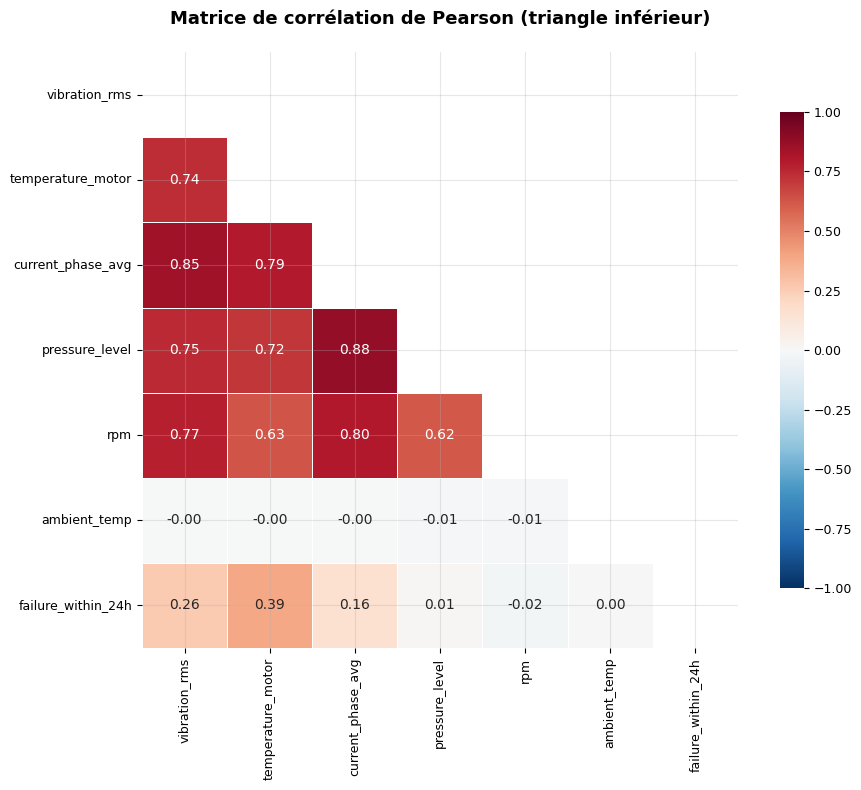


Corrélations avec failure_within_24h (|r| décroissant) :
--------------------------------------------------
  temperature_motor         0.386  █████████
  vibration_rms             0.264  ██████
  current_phase_avg         0.157  ███
  rpm                       0.024  
  pressure_level            0.013  
  ambient_temp              0.004  


In [ ]:
# ── Matrice de corrélation (Pearson) ─────────────────────────
corr_cols   = NUMERIC_COLS + [TARGET]
corr_cols   = [c for c in corr_cols if c in df.columns]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8},
)
ax.set_title('Matrice de corrélation de Pearson (triangle inférieur)', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Corrélations avec la cible
target_corr = (
    corr_matrix[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
)
print(f'\nCorrélations avec {TARGET} (|r| décroissant) :')
print('-' * 50)
for feat, val in target_corr.items():
    bar = chr(9608) * int(val * 25)
    print(f'  {feat:<25} {val:.3f}  {bar}')

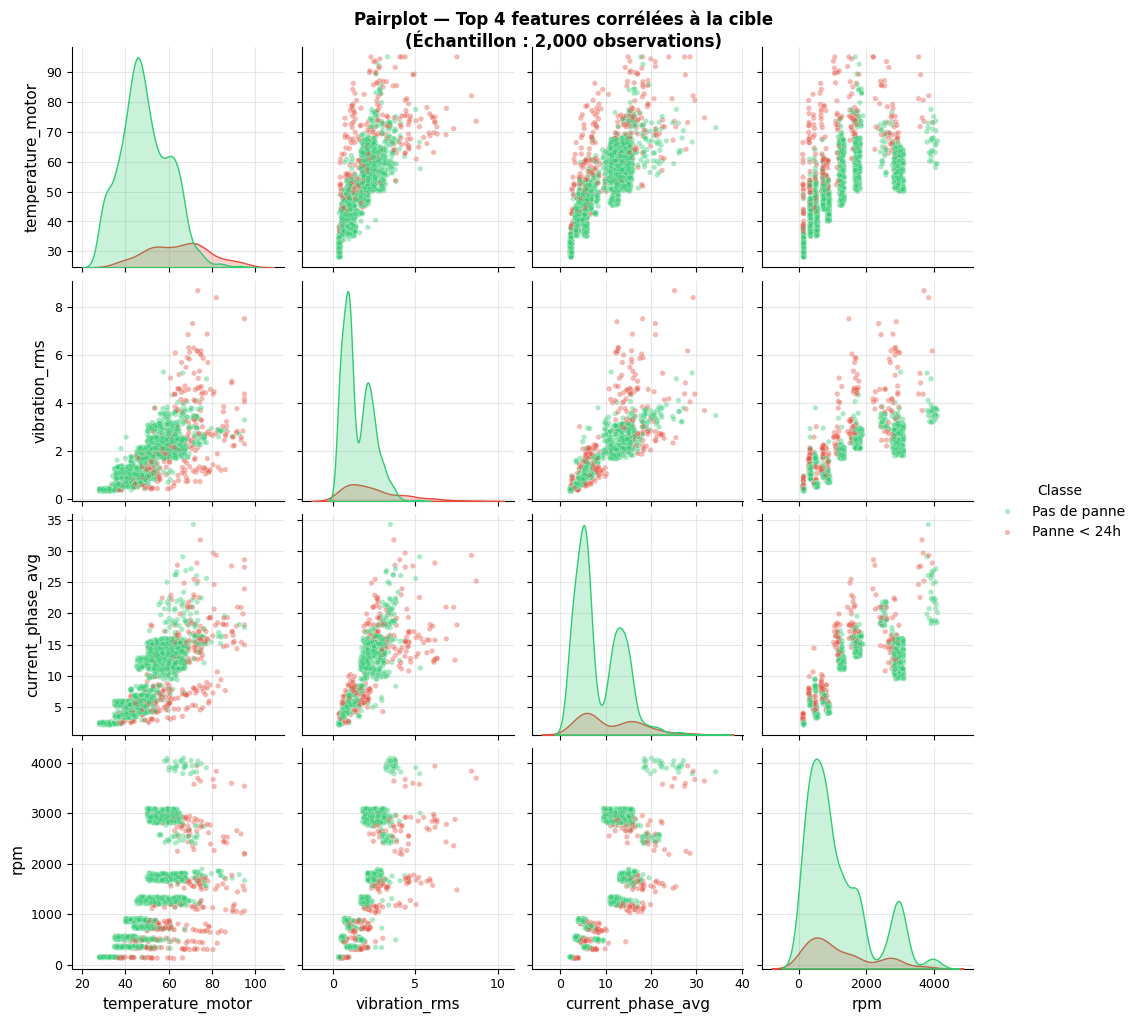

In [ ]:
# ── Pairplot — Top 4 features les plus corrélées ─────────────
sample_size  = min(2000, len(df))
top_features = target_corr.head(4).index.tolist()
plot_cols    = top_features + [TARGET]

df_sample = df.sample(sample_size, random_state=42)
pairplot_data = df_sample[plot_cols].copy()
pairplot_data['Classe'] = pairplot_data[TARGET].map({0: 'Pas de panne', 1: 'Panne < 24h'})

g = sns.pairplot(
    pairplot_data.drop(columns=[TARGET]),
    hue='Classe',
    palette={'Pas de panne': COLOR_OK, 'Panne < 24h': COLOR_FAIL},
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15},
    height=2.5,
)
g.figure.suptitle(
    f'Pairplot — Top {len(top_features)} features corrélées à la cible\n'
    f'(Échantillon : {sample_size:,} observations)',
    y=1.02, fontsize=12, fontweight='bold'
)
plt.show()

---
## Cellule 7 — Valeurs manquantes et doublons

5 colonnes avec des valeurs manquantes :
                   Manquants  Pourcentage (%)
vibration_rms           1000             4.16
pressure_level           924             3.84
temperature_motor        834             3.47
current_phase_avg        731             3.04
rpm                      533             2.22


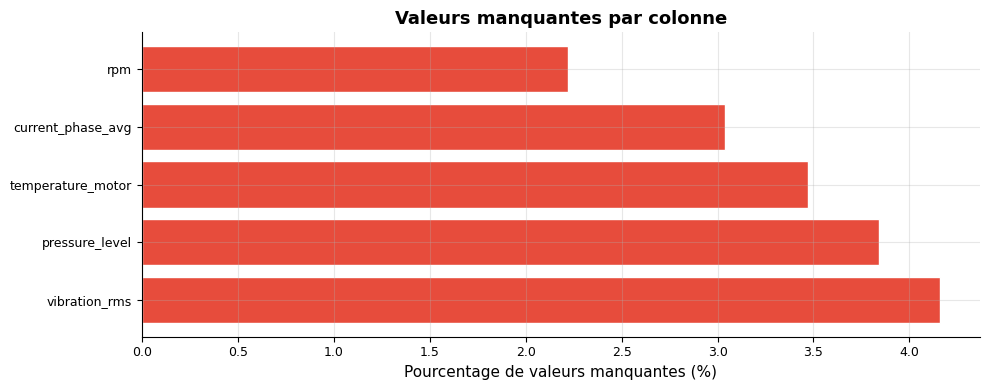

Stratégie de traitement :
  < 5%  : Imputation médiane (num) ou mode (cat)
  5-20% : Imputation + indicateur de manque (colonne binaire)
  > 20% : Suppression ou imputation avancée (KNN)

Doublons : 0
  -> Aucun doublon détecté.


In [ ]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Manquants': missing, 'Pourcentage (%)': missing_pct})
missing_df  = missing_df[missing_df['Manquants'] > 0].sort_values('Manquants', ascending=False)

if len(missing_df) > 0:
    print(f'{len(missing_df)} colonnes avec des valeurs manquantes :')
    print(missing_df.to_string())
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(missing_df.index, missing_df['Pourcentage (%)'], color=COLOR_FAIL, edgecolor='white')
    ax.set_xlabel('Pourcentage de valeurs manquantes (%)')
    ax.set_title('Valeurs manquantes par colonne', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print('Stratégie de traitement :')
    print('  < 5%  : Imputation médiane (num) ou mode (cat)')
    print('  5-20% : Imputation + indicateur de manque (colonne binaire)')
    print('  > 20% : Suppression ou imputation avancée (KNN)')
else:
    print('Aucune valeur manquante détectée.')

n_dup = df.duplicated().sum()
print(f'\nDoublons : {n_dup}')
if n_dup > 0:
    print('  -> Suppression recommandée avant modélisation.')
else:
    print('  -> Aucun doublon détecté.')

---
## Cellule 8 — Analyse des outliers (méthode IQR)

In [ ]:
print(f'{"Feature":<25} {"Q1":>8} {"Q3":>8} {"IQR":>8} {"N outliers":>12} {"Pct":>8}')
print('-' * 74)

for col in NUMERIC_COLS:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = int(((df[col] < lower) | (df[col] > upper)).sum())
    pct   = round(n_out / len(df) * 100, 2)
    flag  = '  !' if pct > 5 else ''
    print(f'  {col:<23} {Q1:>8.2f} {Q3:>8.2f} {IQR:>8.2f} {n_out:>12,} {pct:>7.2f}%{flag}')

print('\nStratégie :')
print('  < 5%  : Conserver (informations potentielles sur les pannes)')
print('  > 5%  : Analyser manuellement avant décision de traitement')
print('  RandomForest et XGBoost sont robustes aux outliers')
print('  MLP et Logistic Regression nécessitent StandardScaler (déjà appliqué)')

Feature                         Q1       Q3      IQR   N outliers      Pct
--------------------------------------------------------------------------
  vibration_rms               0.82     2.27     1.45          478    1.99%
  temperature_motor          42.61    59.96    17.35          219    0.91%
  current_phase_avg           4.63    13.12     8.49          158    0.66%
  pressure_level             22.70    94.70    72.00            1    0.00%
  rpm                       489.40  1676.00  1186.60          373    1.55%
  ambient_temp               10.50    15.50     5.00            0    0.00%

Stratégie :
  < 5%  : Conserver (informations potentielles sur les pannes)
  > 5%  : Analyser manuellement avant décision de traitement
  RandomForest et XGBoost sont robustes aux outliers
  MLP et Logistic Regression nécessitent StandardScaler (déjà appliqué)


---
## Cellule 9 — Patterns de dégradation (RUL × capteurs)

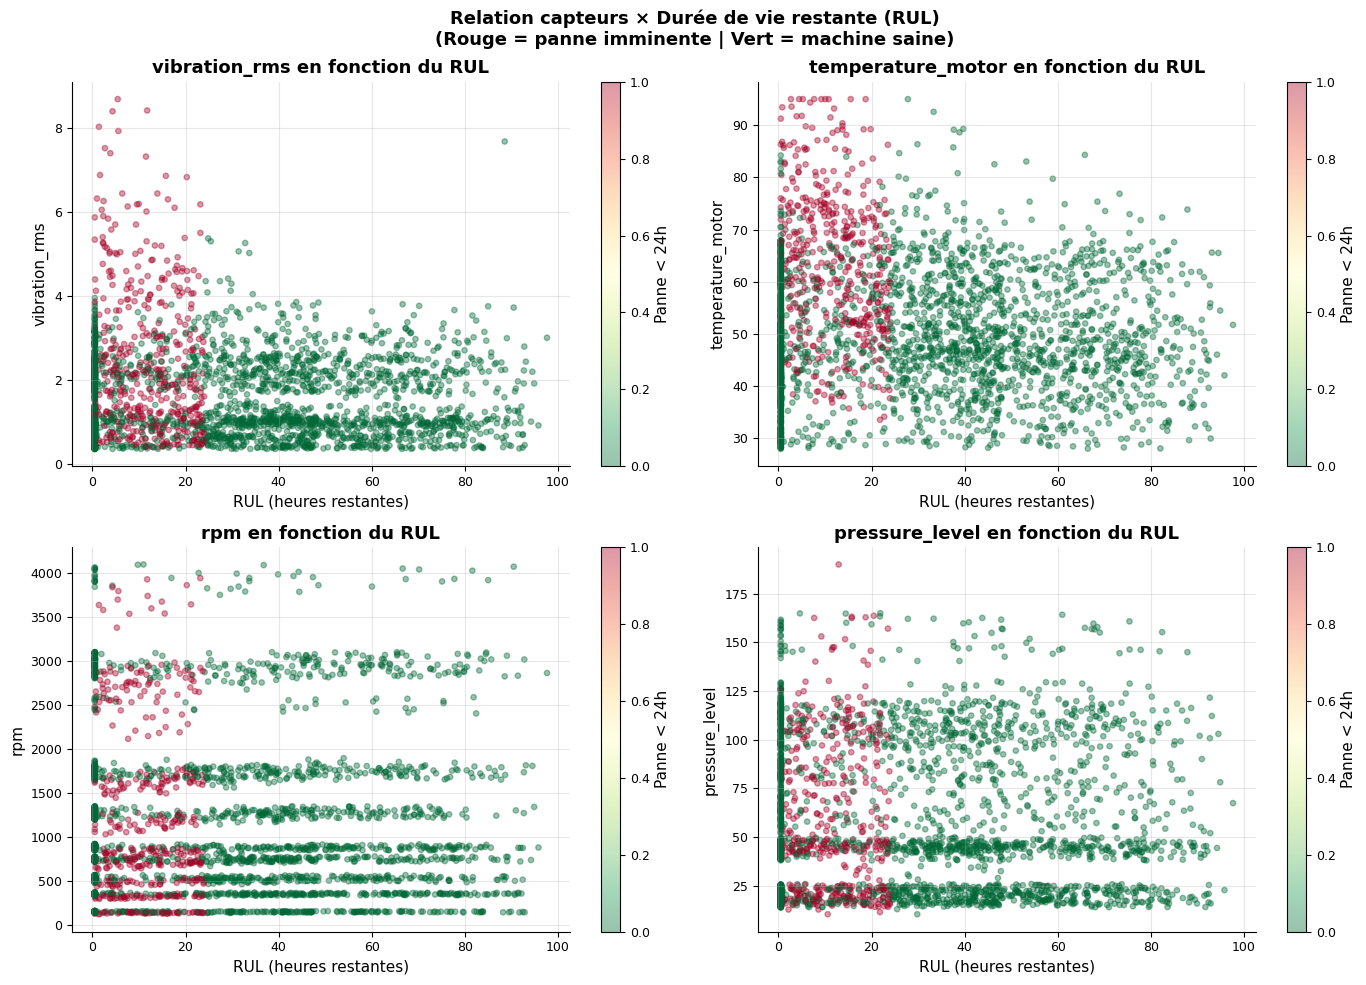

Interprétation :
  Les valeurs élevées de vibration et température se concentrent
  pour de faibles valeurs de RUL -> cohérence physique validée.


In [ ]:
if 'rul_hours' in df.columns:
    features_vs_rul = [c for c in ['vibration_rms', 'temperature_motor', 'rpm', 'pressure_level'] if c in df.columns]
    df_sample = df.sample(min(3000, len(df)), random_state=42)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for idx, feat in enumerate(features_vs_rul[:4]):
        ax = axes[idx // 2][idx % 2]
        sc = ax.scatter(
            df_sample['rul_hours'], df_sample[feat],
            c=df_sample[TARGET], cmap='RdYlGn_r',
            alpha=0.4, s=15,
        )
        ax.set_xlabel('RUL (heures restantes)')
        ax.set_ylabel(feat)
        ax.set_title(f'{feat} en fonction du RUL', fontweight='bold')
        plt.colorbar(sc, ax=ax, label='Panne < 24h')

    plt.suptitle(
        'Relation capteurs × Durée de vie restante (RUL)\n'
        '(Rouge = panne imminente | Vert = machine saine)',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

    print('Interprétation :')
    print('  Les valeurs élevées de vibration et température se concentrent')
    print('  pour de faibles valeurs de RUL -> cohérence physique validée.')
else:
    print('Colonne rul_hours absente du dataset.')

---
## Cellule 10 — Synthèse et recommandations de modélisation

In [ ]:
print('=' * 60)
print('  SYNTHÈSE EDA — RECOMMANDATIONS POUR LA MODÉLISATION')
print('=' * 60)
print('''
1. DÉSÉQUILIBRE DE CLASSES
   -> Classe minoritaire (pannes) generalement < 15%
   -> Actions : stratified split, class_weight='balanced',
      ajustement du seuil de decision, metriques Recall/F1/AUC

2. PREPROCESSING
   -> StandardScaler : obligatoire pour MLP et Logistic Regression
   -> OneHotEncoder  : pour operating_mode (variable categorielle)
   -> Pipeline sklearn : garant contre le data leakage

3. FEATURES PRIORITAIRES
   -> vibration_rms    : forte correlation avec les pannes
   -> temperature_motor: distributions distinctes selon les classes
   -> rul_hours        : directement lie a l'etat de degradation
   -> pressure_level   : signal complementaire

4. MODÈLES (ordre de priorite pedagogique)
   -> Logistic Regression : baseline interpretable
   -> Random Forest       : robuste aux outliers, feature importance
   -> XGBoost             : meilleures performances attendues
   -> MLP                 : Deep Learning obligatoire

5. MÉTRIQUES PRIORITAIRES
   -> Recall  : minimiser les faux negatifs (pannes non detectees)
   -> F1-Score: compromis Precision/Recall
   -> ROC-AUC : robuste au desequilibre
   !! Accuracy seule : trompeuse avec classes desequilibrees
''')
print('=' * 60)

  SYNTHÈSE EDA — RECOMMANDATIONS POUR LA MODÉLISATION

1. DÉSÉQUILIBRE DE CLASSES
   -> Classe minoritaire (pannes) generalement < 15%
   -> Actions : stratified split, class_weight='balanced',
      ajustement du seuil de decision, metriques Recall/F1/AUC

2. PREPROCESSING
   -> StandardScaler : obligatoire pour MLP et Logistic Regression
   -> OneHotEncoder  : pour operating_mode (variable categorielle)
   -> Pipeline sklearn : garant contre le data leakage

3. FEATURES PRIORITAIRES
   -> vibration_rms    : forte correlation avec les pannes
   -> temperature_motor: distributions distinctes selon les classes
   -> rul_hours        : directement lie a l'etat de degradation
   -> pressure_level   : signal complementaire

4. MODÈLES (ordre de priorite pedagogique)
   -> Logistic Regression : baseline interpretable
   -> Random Forest       : robuste aux outliers, feature importance
   -> XGBoost             : meilleures performances attendues
   -> MLP                 : Deep Learning obl